# Gradient-Free Fitting

Not every fitting problem has a usable gradient. The objective might be non-differentiable (a
spike count, a discrete decision), the loss surface might be jagged, or you might be fitting a
black-box metric. For these cases {class}`brainmass.Fitter` exposes two **gradient-free**
backends that search the parameter space directly:

- `backend='nevergrad'` -- evolutionary / population-based optimisers,
- `backend='scipy'` -- the SciPy optimiser family (gradient *and* gradient-free methods).

The headline of {class}`~brainmass.Fitter` is *write the objective once, swap the backend*. We
reuse the **exact same amplitude target** from {doc}`/tutorials/06_fitting_with_gradients` and
solve it three ways, then compare the cost.

:::{note}
The gradient-free backends search a **bounded box** per parameter. The box is derived
automatically from a parameter's transform when that transform defines a finite interval
(e.g. {class}`~brainstate.nn.SigmoidT`). We use `SigmoidT(0.05, 3.0)` so the box is
`(0.05, 3.0)` -- no bounds need to be spelled out.
:::

In [1]:
import brainmass
import brainstate
import braintools
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from brainstate.nn import Param, SigmoidT

brainstate.environ.set(dt=0.1 * u.ms)
brainstate.random.seed(0)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## The same problem as Tutorial 06

A {class}`~brainmass.HopfStep` whose limit-cycle amplitude we match to a target generated at a
known `a* = 1.5`. The only change from the gradient tutorial is the transform: `SigmoidT(0.05,
3.0)` gives the gradient-free search a finite box to explore.

In [2]:
def make_hopf(a, trainable=False):
    a_param = Param(a, t=SigmoidT(0.05, 3.0), fit=True) if trainable else a
    return brainmass.HopfStep(
        in_size=1, a=a_param, w=0.3,
        init_x=braintools.init.Constant(0.5),
        init_y=braintools.init.Constant(0.0),
    )

def settled_amplitude(node):
    res = brainmass.Simulator(node, dt=0.1 * u.ms).run(
        300.0 * u.ms, monitors=['x'], transient=150.0 * u.ms,
    )
    x = u.get_magnitude(res['x'])
    return jnp.sqrt(jnp.mean(x ** 2)) * jnp.sqrt(2.0)

target_amplitude = float(settled_amplitude(make_hopf(1.5)))

def loss_fn(model):                          # the SAME objective for every backend
    amp = settled_amplitude(model)
    return (amp - target_amplitude) ** 2, amp

print(f"target amplitude (true a* = 1.5): {target_amplitude:.4f}")

target amplitude (true a* = 1.5): 1.2296


## Nevergrad (evolutionary search)

`backend='nevergrad'` runs an evolutionary optimiser over the derived box. For the
gradient-free backends the `optimizer` argument is an **options dict** (or a method-name
string), not a `braintools.optim` instance -- here Differential Evolution with `n_sample`
candidates per generation. `n_steps` is the number of generations, so the total number of
simulations is roughly `n_sample x n_steps`.

In [3]:
node = make_hopf(0.1, trainable=True)
ng_result = brainmass.Fitter(
    node,
    {'method': 'DE', 'n_sample': 6},
    loss_fn=loss_fn,
    backend='nevergrad',
).fit(n_steps=12)

print(f"nevergrad: fitted a = {float(ng_result.best_params['a']):.4f}   (true a* = 1.5)")
print(f"           best loss = {ng_result.best_loss:.2e}")
print(f"           simulations = {len(ng_result.history)}")

nevergrad: fitted a = 1.4994   (true a* = 1.5)
           best loss = 5.84e-08
           simulations = 72


## SciPy

`backend='scipy'` runs {class}`braintools.optim.ScipyOptimizer`. Gradient methods such as
`L-BFGS-B` differentiate through the parameter assignment; gradient-free methods such as
`Nelder-Mead` work too. Here `n_steps` is the number of random restarts -- a couple of restarts
make the search robust to a poor starting point.

In [4]:
node = make_hopf(0.1, trainable=True)
sp_result = brainmass.Fitter(
    node,
    {'method': 'Nelder-Mead'},               # a derivative-free SciPy simplex method
    loss_fn=loss_fn,
    backend='scipy',
).fit(n_steps=3)

print(f"scipy: fitted a = {float(sp_result.best_params['a']):.4f}   (true a* = 1.5)")
print(f"       best loss = {sp_result.best_loss:.2e}")

/home/chaoming/miniconda3/lib/python3.13/site-packages/braintools/optim/_scipy_optimizer.py:284: RuntimeWarning: Method Nelder-Mead does not use gradient information (jac).
  results = minimize(


scipy: fitted a = 1.5000   (true a* = 1.5)
       best loss = 1.55e-11


## Gradient vs gradient-free: the cost

For reference we run the **gradient** backend on the identical problem and tally how many
forward simulations each method needed to reach a comparable loss.

In [5]:
# Gradient backend (as in Tutorial 06) for a head-to-head comparison.
node = make_hopf(0.1, trainable=True)
grad_result = brainmass.Fitter(
    node, braintools.optim.Adam(lr=0.1), loss_fn=loss_fn, backend='grad',
).fit(n_steps=60)

# Nevergrad reports one loss per candidate; count its simulations directly.
n_grad = len(grad_result.history)
n_nevergrad = len(ng_result.history)

print(f"{'backend':<12}{'fitted a':>10}{'best loss':>14}{'evaluations':>14}")
print("-" * 50)
print(f"{'grad':<12}{float(grad_result.best_params['a']):>10.4f}{grad_result.best_loss:>14.2e}{n_grad:>14}")
print(f"{'nevergrad':<12}{float(ng_result.best_params['a']):>10.4f}{ng_result.best_loss:>14.2e}{n_nevergrad:>14}")
print(f"{'scipy':<12}{float(sp_result.best_params['a']):>10.4f}{sp_result.best_loss:>14.2e}{'(restarts)':>14}")

backend       fitted a     best loss   evaluations
--------------------------------------------------
grad            1.5220      8.29e-05            60
nevergrad       1.4994      5.84e-08            72
scipy           1.5000      1.55e-11    (restarts)


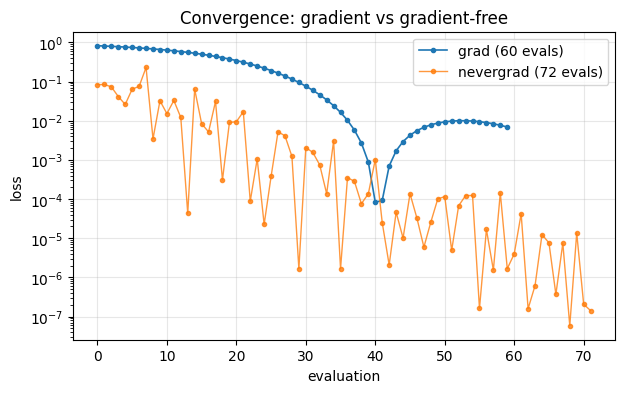

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grad_result.history, marker='.', lw=1.2, label=f'grad ({n_grad} evals)')
ax.plot(ng_result.history, marker='.', lw=1.0, alpha=0.8,
        label=f'nevergrad ({n_nevergrad} evals)')
ax.set_yscale('log')
ax.set_xlabel('evaluation')
ax.set_ylabel('loss')
ax.set_title('Convergence: gradient vs gradient-free')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

The gradient method walks straight downhill -- every step is informed by the derivative, so it
reaches a tiny loss in a few dozen evaluations. The evolutionary search must *sample* the box
to discover the descent direction, so it spends many more simulations to reach a comparable
loss. SciPy's simplex sits in between.

## When to use which

| Situation | Backend |
| --- | --- |
| Differentiable objective, more than a few parameters | `grad` -- by far the most efficient |
| Non-differentiable / discrete / black-box objective | `nevergrad` |
| Few parameters, well-behaved loss, want a robust local search | `scipy` (`L-BFGS-B` or `Nelder-Mead`) |
| Rugged loss with many local minima | `nevergrad` (population escapes local minima) |

The single most important rule: **if you can differentiate the objective, use `grad`.** The
whole reason brainmass models are written as differentiable JAX programs is to make that path
available. Reach for gradient-free search only when the gradient is unavailable or unreliable.

## Summary

- The same objective is fit by `nevergrad`, `scipy`, and `grad` -- only the `backend` (and the
  `optimizer` argument's form) changes.
- Gradient-free backends search a bounded **box** derived from each parameter's transform
  ({class}`~brainstate.nn.SigmoidT` here); pass an explicit `search_space` for unbounded
  transforms.
- Gradient descent reaches the target in far fewer simulations than evolutionary search.

## Next steps

- {doc}`/tutorials/06_fitting_with_gradients` -- the gradient backend in depth.
- {doc}`/tutorials/08_training_on_tasks` -- train a network on a cognitive task over epochs.
- {doc}`/reference/orchestration` -- {class}`~brainmass.Fitter` / {class}`~brainmass.FitResult`
  API and `search_space` derivation.